In [ ]:
%matplotlib ipympl

from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any
import os, math

import numpy as np
from numpy.polynomial.legendre import legvander
import numpy.linalg as npl

import matplotlib.pyplot as plt
import kkcalc
import xraydb


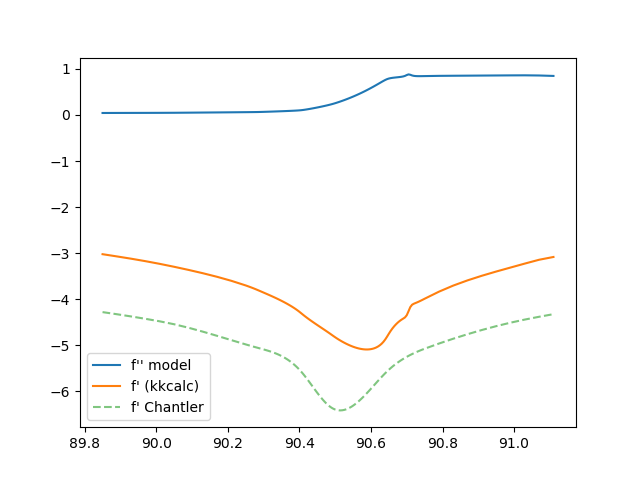

In [2]:
# edge model


@dataclass
class Peak:
    """Lorentzian white-line added to f''.

    Attributes
    ----------
    center_eV : float
        The center energy of the peak in eV.
    fwhm_eV : float
        The full width at half maximum of the peak in eV.
    height : float
        The height of the peak.
    """
    center_eV: float
    fwhm_eV: float
    height: float

@dataclass
class EdgeModelParams:
    """ Parameters for the edge model.

    Attributes
    ----------
    element : str
        The chemical element for the edge model.
    e0_keV : float
        The reference edge energy in keV (for baseline slope origin only).
    dE_eV : float
        Global energy shift in eV (chemical/instrumental).
    scale : float
        Multiplicative scale on f''.
    fpp_offset : float
        Baseline offset.
    fpp_slope_per_eV : float
        Slope of the f'' baseline per eV.
    broaden_fwhm_eV : float
        FWHM for lorentzian broadening in eV.
    peaks : List[Peak]
        The list of peaks to add to the model.
    use_chantler_f2_baseline : bool
        Whether to use Chantler for f'' or measured data.
    """
    element: str = "Bi"
    e0_keV: float = 90.526

    dE_eV: float = 0.0
    scale: float = 1.0
    fpp_offset: float = 0.0
    fpp_slope_per_eV: float = 0.0
    broaden_fwhm_eV: float = 0.0
    peaks: List[Peak] = field(default_factory=list)
    use_chantler_f2_baseline: bool = True


class _BaseEdgeModel:
    """Utilities for edge models."""
    def __init__(self, params: EdgeModelParams):
        self.params = params

    @staticmethod
    def to_eV(E: np.ndarray) -> np.ndarray:
        """Accept 1D energy in eV or keV; return in eV."""
        E = np.asarray(E, dtype=float)
        scale = 1.0 if np.nanmax(E) >= 1e3 else 1e3
        return E * scale

    @staticmethod
    def lorentzian_height(E: np.ndarray, center: float, fwhm: float, height: float) -> np.ndarray:
        """Lorentzian peak shape."""
        gamma = 0.5 * max(float(fwhm), 1e-18)
        return height * (gamma**2) / ((E - center) ** 2 + gamma**2)

    @staticmethod
    def broadening(E_eV: np.ndarray, y: np.ndarray, fwhm_eV: float) -> np.ndarray:
        """Lorentzian broadening via uniform helper grid + convolution."""
        if fwhm_eV <= 0.0:
            return y
        Emin, Emax = float(E_eV[0]), float(E_eV[-1])
        dmins = float(np.min(np.diff(E_eV)))
        d_helper = max(min(dmins / 4.0, fwhm_eV / 25.0), 1e-3)
        pad = max(5.0 * fwhm_eV, 10.0 * dmins)
        Xu = np.arange(Emin - pad, Emax + pad + d_helper, d_helper)
        yu = np.interp(Xu, E_eV, y)

        gamma = 0.5 * float(fwhm_eV)
        Lx = np.arange(-10.0 * fwhm_eV, 10.0 * fwhm_eV + d_helper, d_helper)
        Lk = (gamma / np.pi) / (Lx**2 + gamma**2)
        Lk /= Lk.sum()
        conv = np.convolve(yu, Lk, mode="same")
        return np.interp(E_eV, Xu, conv)


class KKCalcAdapter:
    """Wrap kkcalc: tails, relativistic anchor, and KK on grid."""
    def __init__(self, element: str):
        self.stoich = kkcalc.data.ParseChemicalFormula(element)
        self.rc = kkcalc.calc_relativistic_correction(self.stoich)
        self.full_E, self.full_imag_coeffs = kkcalc.data.calculate_asf(self.stoich)

    def f1_from_f2(self,
                   energy_eval_eV: np.ndarray,
                   near_edge_f2_vals: Optional[np.ndarray],
                   merge_points: Optional[Tuple[float, float]] = None,
                   add_background: bool = False,
                   fix_distortions: bool = False) -> Tuple[np.ndarray, np.ndarray, float]:
        """
        Compute f1(E) on `energy_eval_eV` grid by merging near-edge f2(E) into kkcalc's tails 
        then applying kkcalc's Kramers–Kronig KKPP.

        Parameters
        ----------
        energy_eval_eV : np.ndarray
            1D energy grid in eV where f1(E) is evaluated.
        near_edge_f2_vals : Optional[np.ndarray]
            1D array of f'' values on the same grid as `energy_eval_eV`.
            If None, only tabulated tails are used.
        merge_points : Optional[Tuple[float, float]]
            If provided, the (low, high) energy in eV where near-edge and tabulated tails are merged.
            If None, the full near-edge range is used.
        add_background : bool
            If True, a linear background is added to the tabulated tails to match the near-edge
            at the merge points.
        fix_distortions : bool
            If True, a small quadratic distortion is applied to the tabulated tails to ensure
            that the near-edge and tails match in slope at the merge points.

        Returns
        -------
        Tuple[np.ndarray, np.ndarray, float]
            1D array of f1 values on `energy_eval_eV` grid,
            1D array of f2 values on `energy_eval_eV` grid (from coeff representation),
            the relativistic correction.
        """
        E = np.asarray(energy_eval_eV, float)
        if near_edge_f2_vals is not None:
            NearEdge_Data = np.column_stack([E, np.asarray(near_edge_f2_vals, float)])
            mp = (float(E[0]), float(E[-1])) if merge_points is None else merge_points
            Full_E, Imaginary_Spectrum = kkcalc.data.merge_spectra(
                NearEdge_Data, self.full_E, self.full_imag_coeffs,
                merge_points=mp, add_background=add_background, fix_distortions=fix_distortions
            )
        else:
            Full_E, Imaginary_Spectrum = self.full_E, self.full_imag_coeffs

        f1_vals = kkcalc.KK_PP(E, Full_E, Imaginary_Spectrum, self.rc)

        i1 = np.searchsorted(Full_E, E[0], side="right") - 1
        i2 = np.searchsorted(Full_E, E[-1], side="right") - 1
        i1 = max(i1, 0)
        i2 = max(i2, i1 + 1)
        f2_vals = kkcalc.data.coeffs_to_ASF(E, np.vstack((Imaginary_Spectrum[i1:i2], Imaginary_Spectrum[-1])))
        return f1_vals, f2_vals, float(self.rc)


class EdgeModel(_BaseEdgeModel):
    r"""
    Near-edge f'' model + kkcalc KK step.
    - Build f''(E) near the edge (from Chantler or measured data/zeros), apply shift/scale/offset/slope baseline,
      add Lorentzian white-lines, lorentzian broadening conv.
    - Call kkcalc to merge near-edge f'' with tabulated tails and compute f1(E).
    - Return f'(E) = f1(E) - f1(\infty) by default or optionally return f1(E).
    """
    def __init__(self, params: EdgeModelParams):
        super().__init__(params)
        self.kk = KKCalcAdapter(params.element)

    def fpp(self, E: np.ndarray) -> np.ndarray:
        E_eV = self.to_eV(E)
        E_eval = E_eV + float(self.params.dE_eV)

        if self.params.use_chantler_f2_baseline:
            f2 = np.asarray(xraydb.f2_chantler(self.params.element, E_eval), float)
        else:
            f2 = np.zeros_like(E_eval)

        f2 = float(self.params.scale) * f2
        f2 += float(self.params.fpp_offset)
        f2 += float(self.params.fpp_slope_per_eV) * (E_eV - float(self.params.e0_keV) * 1e3)

        if self.params.peaks:
            add = np.zeros_like(f2)
            for pk in self.params.peaks:
                add += self.lorentzian_height(E_eval, pk.center_eV, pk.fwhm_eV, pk.height)
            f2 = f2 + add

        f2 = self.broadening(E_eV, f2, self.params.broaden_fwhm_eV)
        return f2

    def fp(self,
           E: np.ndarray,
           fpp: Optional[np.ndarray] = None,
           return_f1: bool = False,
           merge_points: Optional[Tuple[float, float]] = None,
           add_background: bool = False,
           fix_distortions: bool = False) -> np.ndarray:
        r"""
        Return f'(E) and optionally f1(E) using kkcalc.

        Parameters
        ----------
        E : np.ndarray
            1D energy grid in eV or keV where f' is evaluated.
        fpp : Optional[np.ndarray]
            Custom 1D array of f'' values, on the same grid as `E`.
        return_f1 : bool
            If True, return f1(E) instead of f'(E) = f1(E) - f1(\infty).
        merge_points : Optional[Tuple[float, float]]
            If provided, the (low, high) energy in eV where near-edge and tabulated tails are merged.
            If None, the full near-edge range is used.
        add_background : bool
            If True, a linear background is added to the tabulated tails to match the near-edge
            at the merge points.
        fix_distortions : bool
            If True, a small quadratic distortion is applied to the tabulated tails to ensure
            that the near-edge and tails match in slope at the merge points.
        """
        E_eV = self.to_eV(E)
        E_eval = E_eV + float(self.params.dE_eV)

        if fpp is None:
            fpp = self.fpp(E_eV)

        f1_vals, f2_vals, f1_inf = self.kk.f1_from_f2(
            energy_eval_eV=E_eval,
            near_edge_f2_vals=fpp,
            merge_points=merge_points,
            add_background=add_background,
            fix_distortions=fix_distortions
        )
        return f1_vals if return_f1 else (f1_vals - f1_inf)


# Example

E = np.array([
    89.85, 89.89, 89.93, 89.97, 90.01, 90.05, 90.09, 90.13, 90.17, 90.21,
    90.25, 90.255, 90.26, 90.265, 90.27, 90.275, 90.28, 90.285, 90.29, 90.295,
    90.3, 90.305, 90.31, 90.315, 90.32, 90.325, 90.33, 90.335, 90.34, 90.345,
    90.35, 90.355, 90.36, 90.365, 90.37, 90.375, 90.38, 90.385, 90.39, 90.395,
    90.4, 90.405, 90.41, 90.415, 90.42, 90.425, 90.43, 90.435, 90.44, 90.445,
    90.45, 90.455, 90.46, 90.465, 90.47, 90.475, 90.48, 90.485, 90.49, 90.495,
    90.5, 90.505, 90.51, 90.515, 90.52, 90.525, 90.53, 90.535, 90.54, 90.545,
    90.55, 90.555, 90.56, 90.565, 90.57, 90.575, 90.58, 90.585, 90.59, 90.595,
    90.6, 90.605, 90.61, 90.615, 90.62, 90.625, 90.63, 90.635, 90.64, 90.645,
    90.65, 90.655, 90.66, 90.665, 90.67, 90.675, 90.68, 90.685, 90.69, 90.695,
    90.7, 90.705, 90.71, 90.715, 90.72, 90.725, 90.73, 90.735, 90.74, 90.745,
    90.75, 90.79, 90.83, 90.87, 90.91, 90.95, 90.99, 91.03, 91.07, 91.11
])

params = EdgeModelParams(
    element="Bi",
    e0_keV=90.526,
    dE_eV=0.0,
    scale=0.35,
    fpp_offset=-0.2,
    fpp_slope_per_eV=0.0,
    broaden_fwhm_eV=15.0,
    peaks=[Peak(center_eV=90.526e3 + 180, fwhm_eV=3.0, height=0.3)],
    use_chantler_f2_baseline=True,
)

model = EdgeModel(params)

fpp = model.fpp(E)
fp = model.fp(E, fpp=fpp)
f1 = model.fp(E, fpp=fpp, return_f1=True)
fp_chantler = xraydb.f1_chantler(params.element, model.to_eV(E) + params.dE_eV)

plt.figure()
plt.plot(E, fpp, label="f'' model")
plt.plot(E, fp,  label="f' (kkcalc)")
plt.plot(E, fp_chantler, "--", alpha=0.6, label="f' Chantler")
plt.legend()
plt.show()


In [3]:
# utils

def _as_1d(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a)
    return a.ravel()

def _safe(a: np.ndarray, name: str) -> np.ndarray:
    if not np.all(np.isfinite(a)):
        idx = np.where(~np.isfinite(a))
        raise ValueError(f"{name} has non-finite entries at {idx}")
    return a

def _lorch(Q: np.ndarray, Qmax: float) -> np.ndarray:
    x = Q / Qmax
    w = np.ones_like(Q)
    m = (x > 0) & (x <= 1.0)
    w[m] = np.sin(np.pi * x[m]) / (np.pi * x[m])
    w[x > 1.0] = 0.0
    return w

def _kaiser(Q: np.ndarray, Qmax: float, beta: float = 6.0) -> np.ndarray:
    from numpy import i0
    x = Q / Qmax
    w = np.zeros_like(Q)
    m = (x >= 0) & (x <= 1.0)
    w[m] = i0(beta * np.sqrt(1.0 - x[m]**2)) / i0(beta)
    return w

def _trapz(x: np.ndarray, y: np.ndarray) -> float:
    return float(np.trapezoid(y, x))

def _ensure_2d(x: np.ndarray, ne: int, nq: int, name: str) -> np.ndarray:
    x = np.asarray(x, float)
    if x.ndim == 0:
        return np.full((ne, nq), float(x))
    if x.ndim == 1:
        if x.size == ne:
            return x[:, None] * np.ones((1, nq))
        if x.size == nq:
            return np.ones((ne, 1)) * x[None, :]
        raise ValueError(f"{name} 1D length {x.size} mismatches ne={ne}, nq={nq}")
    if x.shape != (ne, nq):
        raise ValueError(f"{name} shape {x.shape} != ({ne},{nq})")
    return x


In [4]:
# config

@dataclass
class RefinementConfig:
    # S(Q) construction
    poly_deg: int = 2
    hiQ_frac: float = 0.85
    Q_anchor_min: float = 25.0
    ridge: float = 8e-4
    anchor_weight: float = 1.5
    # G(r)
    window: str = "lorch"    # "none"/"lorch"/"kaiser"
    kaiser_beta: float = 6.0
    rmin: float = 0.0
    rmax: float = 20.0
    dr: float = 0.01
    Qmin: float = 0.1
    Qmax: Optional[float] = None
    # outer refinement
    n_outer: int = 40
    plot_every: int = 2
    frame_dir: str = "./refine_frames"
    # parameter step sizes
    step_dE_eV: float = 2.0
    step_scale: float = 0.05
    step_fpp_offset: float = 0.05
    step_fp_offset: float = 0.05
    step_broaden_fwhm: float = 2.0
    step_alphaC: float = 0.05
    step_alphaD: float = 0.05
    step_betaC: float = 0.05
    step_betaD: float = 0.05
    # peak step sizes
    step_peak_center_eV: float = 4.0
    step_peak_fwhm_eV: float = 1.0
    step_peak_height: float = 0.05
    # physical constraints
    min_broaden_fwhm_eV: float = 0.0
    max_broaden_fwhm_eV: float = 40.0
    min_peak_fwhm_eV: float = 0.5
    max_peak_fwhm_eV: float = 30.0
    max_peak_height_factor: float = 1.0
    # objective pieces
    hiQ_anchor_lambda: float = 1.0
    smooth_lambda: float = 1e-4
    peak_L1_lambda: float = 1e-3
    # peak birth/death controls
    birth_every: int = 4
    death_height_thresh: float = 1e-2

@dataclass
class RefinementHistory:
    it: int
    obj: float
    params: Dict[str, float]


In [5]:
# scattering factors & weights

def _f0_of_Q(element: str, Q: np.ndarray) -> np.ndarray:
    s = _as_1d(Q) / (4.0 * np.pi)
    f0 = np.array([xraydb.f0(element, si)[0] for si in s], dtype=float)
    return _safe(f0, f"f0({element})")

def _compute_scattering(
    elements: List[str],
    comp: Dict[str, float],
    alpha: str,
    Q: np.ndarray,
    E_eV: np.ndarray,
    edge_model: Any,
    fp_offset: float = 0.0,
) -> Tuple[Dict[str,np.ndarray], Dict[str,np.ndarray], np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
      fr_weights : Re f_el(E,Q) [ne,nq]
      f0_map[el] : f0(Q) [nq]
      fmean_real : <f> (real) [ne,nq]
      fself : <|f|^2> [ne,nq]
      f_not_sum : sum_{beta!=alpha} c_beta * Re f_beta  [ne,nq]
    """
    Q = _as_1d(Q); E = _as_1d(E_eV)
    nq, ne = len(Q), len(E)
    f0_map = {el: _f0_of_Q(el, Q) for el in elements}

    # alpha dispersive parts
    fp = edge_model.fp(E, return_f1=False)
    fpp = edge_model.fpp(E)
    fpp = np.maximum(fpp, 0.0) # enforce physical non-negativity
    _safe(fp, "f'"); _safe(fpp, "f''")

    fr_weights: Dict[str,np.ndarray] = {}
    f2_weights: Dict[str,np.ndarray] = {}

    for el in elements:
        f0 = f0_map[el]
        if el == alpha:
            fr = (fp + fp_offset)[:, None] + f0[None, :]
            fi = fpp[:, None]
        else:
            fr = f0[None, :]
            fi = np.zeros((ne, 1))
        fr_weights[el] = fr
        f2_weights[el] = fr**2 + fi**2

    fmean_real = np.zeros((ne, nq), float)
    fmean_abs2 = np.zeros((ne, nq), float)
    f_not_sum  = np.zeros((ne, nq), float)
    for el in elements:
        c = float(comp[el])
        fmean_real += c * fr_weights[el]
        fmean_abs2 += c * f2_weights[el]
        if el != alpha:
            f_not_sum += c * fr_weights[el]
    fself = fmean_abs2
    return fr_weights, f0_map, fmean_real, fmean_abs2, fself, f_not_sum

def _weights_alpha_not(
    comp: Dict[str, float],
    alpha: str,
    fr_weights: Dict[str, np.ndarray],
    fmean_real: np.ndarray,
    f_not_sum: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, Dict[str,float]]:
    cA = float(comp[alpha]); eps = 1e-12
    a = cA * fr_weights[alpha] / (fmean_real + eps)
    b = f_not_sum / (fmean_real + eps)
    # cap extreme weights to avoid blowing up the per-Q solve
    a = np.clip(a, -5.0, 5.0)
    b = np.clip(b, -5.0, 5.0)
    return a, b, {
        "a_min": float(np.nanmin(a)), "a_max": float(np.nanmax(a)),
        "b_min": float(np.nanmin(b)), "b_max": float(np.nanmax(b)),
        "b_frac_neg": float(np.mean(b < -1e-8))
    }


In [6]:
# corrections & S(Q,e)

def _alpha_beta_from_fpp(fpp_E: np.ndarray, alpha_C: float, alpha_D: float,
                         beta_C: float, beta_D: float) -> Tuple[np.ndarray,np.ndarray]:
    alpha_e = np.clip(alpha_C + alpha_D * fpp_E, 1e-6, None)
    beta_e  = beta_C + beta_D * fpp_E
    return alpha_e, beta_e


def _build_S_from_raw(
    I_raw: np.ndarray, Q: np.ndarray, E_eV: np.ndarray,
    alpha_e: np.ndarray, beta_f_e: np.ndarray,
    fmean_real: np.ndarray, fself: np.ndarray,
    poly_deg: int, hiQ_mask: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """Return S(ne,nq) and beta_o(ne,nq) with correct FZ normalization."""
    I_raw = np.asarray(I_raw, float)
    E = _as_1d(E_eV); Q = _as_1d(Q)
    ne, nq = len(E), len(Q)
    if I_raw.shape != (ne, nq):
        raise ValueError("I_raw must be shaped [ne, nq]")

    I_corr = I_raw * alpha_e[:, None] + beta_f_e[:, None]
    S0 = (I_corr - fself) / (fmean_real**2 + 1e-12) + 1.0

    # β_o(Q,e): polynomial in Q fitted only on hiQ to drive S→1 there
    X = np.vstack([Q**k for k in range(poly_deg + 1)]).T  # [nq,p]
    Xh = X[hiQ_mask]
    XtXh = Xh.T @ Xh + 1e-12*np.eye(Xh.shape[1])
    beta_o = np.zeros_like(S0)
    for i in range(ne):
        y = (1.0 - S0[i]) * (fmean_real[i]**2)
        coeff = npl.solve(XtXh, Xh.T @ y[hiQ_mask])
        beta_o[i] = (X @ coeff) / (fmean_real[i]**2 + 1e-12)
    S = S0 + beta_o

    # sample = np.linspace(0, ne-1, 24, dtype=int)
    # for i in sample:
    #     plt.figure()
    #     plt.plot(Q, S0[i], label="S0")
    #     plt.plot(Q, beta_o[i], label="beta_o")
    #     plt.plot(Q, S[i], label="S")
    #     plt.axhline(1.0, color="k", ls="--")
    #     plt.title(f"E={E[i]:.2f} eV")
    #     plt.legend()
    #     plt.show()

    return S, beta_o

# per-Q reconstruction

def _solve_two_channel_column(Aj: np.ndarray, yj: np.ndarray,
                              ridge: float, anchor: float) -> Tuple[float,float]:
    """Solve min ||Aj x - yj||^2 + ridge||x||^2 + anchor||x-1||^2."""
    ATA = Aj.T @ Aj + ridge*np.eye(2) + anchor*np.eye(2)
    ATy = Aj.T @ yj + anchor*np.array([[1.0],[1.0]])
    try:
        sol = npl.solve(ATA, ATy)
    except npl.LinAlgError:
        print("WARNING: singular matrix in _solve_two_channel_column; using lstsq")
        sol = npl.lstsq(ATA, ATy, rcond=None)[0]
    return float(sol[0,0]), float(sol[1,0])

def _reconstruct_Salpha_Snot(
    S_meas: np.ndarray, a: np.ndarray, b: np.ndarray,
    Q: np.ndarray, ridge: float, anchor_weight: float,
    hiQ_mask: np.ndarray
) -> Tuple[np.ndarray,np.ndarray, Dict[str,float]]:
    """Column-wise two-channel solve with conditioning checks and hiQ anchor."""
    S_meas = np.asarray(S_meas, float)

    # !!!!!
    for i in range(S_meas.shape[0]):
        S_meas[i][:40] = S_meas[i][41]

    ne, nq = S_meas.shape
    a = _ensure_2d(a, ne, nq, "a"); b = _ensure_2d(b, ne, nq, "b")

    Sa = np.zeros(nq); Sb = np.zeros(nq)
    bad_cols = 0
    for j in range(nq):
        Aj = np.stack([a[:,j], b[:,j]], axis=1)  # [ne,2]
        yj = S_meas[:, j:j+1]                    # [ne,1]
        # condition
        s = npl.svd(Aj, compute_uv=False)
        cond = (s[0]/s[-1]) if (s[-1] > 0) else np.inf
        anchor = anchor_weight if hiQ_mask[j] else 0.0
        if not np.isfinite(cond) or cond > 1e6:
            bad_cols += 1
            anchor = max(anchor, 5.0)  # heavy anchor to 1 if ill-conditioned
        sa, sb = _solve_two_channel_column(Aj, yj, ridge, anchor)
        Sa[j], Sb[j] = sa, sb

    return Sa, Sb, {"bad_Q_columns": bad_cols}

# S(Q) -> G(r)

def _S_to_G(Q: np.ndarray, S: np.ndarray, r: np.ndarray,
            window: str, kbeta: float) -> np.ndarray:
    Q = _as_1d(Q); S = _as_1d(S); r = _as_1d(r)
    Qmax = float(Q.max())
    w = np.ones_like(Q)
    if window == "lorch":   w = _lorch(Q, Qmax)
    elif window == "kaiser": w = _kaiser(Q, Qmax, kbeta)
    F = Q * (S - 1.0) * w
    G = np.zeros_like(r)
    for i, ri in enumerate(r):
        G[i] = (2.0/np.pi) * _trapz(Q, F*np.sin(Q*ri))
    return G


In [7]:
# plotting

def _plot_frame(path: str, E_eV: np.ndarray, edge_model: Any,
                r: np.ndarray, out: Dict[str,np.ndarray],
                Q_full: np.ndarray, iter_idx: int,
                hist: List[RefinementHistory], fp_offset: float) -> None:
    q = np.asarray(out.get("Q", Q_full))
    Sa = np.asarray(out["S_alpha"]); Sb = np.asarray(out["S_not"])
    St = np.asarray(out["S_tot"])
    m = min(q.size, Sa.size, Sb.size, St.size)
    q, Sa, Sb, St = q[:m], Sa[:m], Sb[:m], St[:m]

    r_plot = np.asarray(r)
    Ga = np.asarray(out["G_alpha"]); Gn = np.asarray(out["G_not"]); Gt = np.asarray(out["G_tot"])
    mG = min(r_plot.size, Ga.size, Gn.size, Gt.size)
    r_plot, Ga, Gn, Gt = r_plot[:mG], Ga[:mG], Gn[:mG], Gt[:mG]

    E = np.asarray(E_eV, float)
    fpp = np.maximum(edge_model.fpp(E), 0.0)
    fp  = edge_model.fp(E, fpp=fpp) + fp_offset
    E_keV = E/1e3

    plt.figure(figsize=(12,20))
    plt.suptitle(f"Refinement frame {iter_idx:03d}")

    ax1 = plt.subplot(4,2,1)
    ax1.plot(E_keV, fpp, label="f'' (model)")
    ax1.set_xlabel("Energy (keV)")
    ax1.set_ylabel("f'' (e−)")
    ax1.set_title("Edge model (f'')")
    ax1.legend(loc="upper left")

    ax2 = plt.subplot(4,2,2)
    ax2.plot(E_keV, fp, label="f' (KK from model) + fp_offset")
    ax2.set_xlabel("Energy (keV)")
    ax2.set_ylabel("f' (e−)")
    ax2.set_title("Edge model (f')")
    ax2.legend(loc="upper left")

    ax = plt.subplot(4,1,2)
    ax.plot(r_plot, Ga, 'b-', label="G_alpha")
    ax.plot(r_plot, Gn, 'g-', label="G_not")
    ax.plot(r_plot, Gt, "r-", label="G_tot (mean S)")
    ax.set_xlabel("r (Å)"); ax.set_ylabel("G(r)"); ax.set_title("PDFs")
    ax.legend(loc="upper right")

    ax = plt.subplot(4,1,3)
    ax.plot(q, Sa, 'b-', label="S_alpha", linewidth=.5)
    ax.plot(q, Sb, 'g-', label="S_not", linewidth=.5)
    ax.plot(q, St, "r-", label="S_tot (mean over E)", linewidth=.5)
    ax.plot(q, np.ones_like(q), 'k-', label="S=1", linewidth=0.1)
    ax.set_xlabel("Q (Å$^{-1}$)"); ax.set_ylabel("S(Q)"); ax.set_title("Structure functions")
    ax.legend(loc="upper left")

    ax = plt.subplot(4,1,4)
    its = np.arange(len(hist)); vals = np.array([h.obj for h in hist], float)
    ax.plot(its, vals, "-o")
    ax.set_yscale('log')
    p = hist[-1].params
    txt = (f"dE_eV={p['dE_eV']:.3g}\nscale={p['scale']:.3g}\n"
           f"fpp_offset={p['fpp_offset']:.3g}\nfp_offset={p['fp_offset']:.3g}\n"
           f"broaden_fwhm_eV={p['broaden_fwhm_eV']:.3g}\n"
           f"alpha_C={p['alpha_C']:.3g}, alpha_D={p['alpha_D']:.3g}\n"
           f"beta_C={p['beta_C']:.3g}, beta_D={p['beta_D']:.3g}")
    ax.text(0.02, 0.98, txt, va="top", ha="left", transform=ax.transAxes,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
    ax.set_xlabel("Iteration"); ax.set_ylabel("Objective"); ax.set_title("Objective history")

    plt.savefig(path, dpi=300); plt.close()


In [8]:
# objective

def _objective(Sa: np.ndarray, Sb: np.ndarray, Q: np.ndarray,
               hiQ_frac: float, anchor_lambda: float) -> float:
    nq = len(Q); k0 = int(max(0, math.floor((1.0-hiQ_frac)*nq)))
    mask = np.zeros(nq, bool); mask[k0:] = True
    tails = np.sum((Sa[mask]-1.0)**2 + (Sb[mask]-1.0)**2)
    d2a = np.diff(Sa, n=2); d2b = np.diff(Sb, n=2)
    smooth = np.sum(d2a**2 + d2b**2)
    physics = np.sum((Sa - Sb)**2)
    return float(anchor_lambda*tails + smooth + physics)

def _hiQ_stats(S: np.ndarray, Q: np.ndarray, hiQ_frac: float) -> Dict[str,float]:
    nq = len(Q); k0 = int(max(0, math.floor((1.0-hiQ_frac)*nq)))
    x = Q[k0:]; y = S[k0:]
    if x.size < 2:
        return {"mean": float(np.mean(y)), "slope": 0.0, "std": float(np.std(y))}
    A = np.vstack([x, np.ones_like(x)]).T
    m, c = npl.lstsq(A, y, rcond=None)[0]
    return {"mean": float(np.mean(y)), "slope": float(m), "std": float(np.std(y))}

# reconstruction

def reconstruct_partials_and_pdfs(
    I_raw: np.ndarray, Q: np.ndarray, E_eV: np.ndarray,
    elements: List[str], comp: Dict[str,float], alpha: str,
    edge_model: Any,
    alpha_e: np.ndarray, beta_e: np.ndarray,
    poly_deg: int, hiQ_frac: float,
    ridge: float, anchor_weight: float,
    r: np.ndarray, Qmin: float, Qmax: float,
    window: str = "lorch", kaiser_beta: float = 6.0,
    fp_offset: float = 0.0,
) -> Tuple[Dict[str,np.ndarray], Dict[str,Any]]:
    Q = _as_1d(Q); E = _as_1d(E_eV)
    I_raw = np.asarray(I_raw, float)
    ne, nq = len(E), len(Q)
    if I_raw.shape != (ne, nq):
        raise ValueError(f"I_raw shape {I_raw.shape} but expected ({ne},{nq})")

    # scattering & weights (with fp_offset applied only to alpha’s real part)
    frw, f0_map, fmean_real, fmean_abs2, fself, f_not_sum = _compute_scattering(
        elements, comp, alpha, Q, E, edge_model, fp_offset=fp_offset
    )
    a, b, wb = _weights_alpha_not(comp, alpha, frw, fmean_real, f_not_sum)

    # Q masks
    if Qmax is None: Qmax = float(Q.max())
    mask_Q = (Q >= Qmin) & (Q <= Qmax)
    Q_use = Q[mask_Q]; nq_use = Q_use.size

    # hiQ anchor mask (absolute + fractional)
    hiQ_abs = (Q >= max(Qmin,  cfg.Q_anchor_min if 'cfg' in globals() else 20.0))
    hiQ_fr  = np.zeros_like(Q, bool); hiQ_fr[int((1.0-hiQ_frac)*nq):] = True
    hiQ_mask = (hiQ_abs & hiQ_fr)[mask_Q]

    # build S(Q,e)
    S_meas_all, beta_o_all = _build_S_from_raw(I_raw, Q, E, alpha_e, beta_e, fmean_real, fself,
                                               poly_deg, hiQ_abs & hiQ_fr)
    S_meas = S_meas_all[:, mask_Q]
    a = a[:, mask_Q]; b = b[:, mask_Q]

    # per-Q two-channel solve
    Sa, Sb, condinfo = _reconstruct_Salpha_Snot(S_meas, a, b, Q_use, ridge, anchor_weight, hiQ_mask)

    # PDFs
    r = _as_1d(r)
    S_tot = S_meas[0]
    G_alpha = _S_to_G(Q_use, Sa, r, window, kaiser_beta)
    G_not   = _S_to_G(Q_use, Sb, r, window, kaiser_beta)
    G_tot   = _S_to_G(Q_use, S_tot, r, window, kaiser_beta)

    out = {"Q": Q_use, "r": r,
           "S_alpha": Sa, "S_not": Sb, "S_tot": S_tot,
           "G_alpha": G_alpha, "G_not": G_not, "G_tot": G_tot}
    diag = {"weights": wb,
            "condinfo": condinfo,
            "beta_o": beta_o_all,
            "hiQ_stats": {"S_alpha": _hiQ_stats(Sa, Q_use, hiQ_frac),
                          "S_not":   _hiQ_stats(Sb, Q_use, hiQ_frac),
                          "S_tot":   _hiQ_stats(S_tot, Q_use, hiQ_frac)}}
    return out, diag


In [9]:
# outer refinement

def _peak_bounds_guard(edge_model: Any, cfg: RefinementConfig, E_eV: np.ndarray) -> None:
    Emin, Emax = float(E_eV.min())-20.0, float(E_eV.max())+40.0
    base = np.maximum(edge_model.fpp(E_eV), 0.0)
    baseline_med = float(np.median(base))
    for pk in edge_model.params.peaks:
        pk.center_eV = float(np.clip(pk.center_eV, Emin, Emax))
        pk.fwhm_eV   = float(np.clip(pk.fwhm_eV, cfg.min_peak_fwhm_eV, cfg.max_peak_fwhm_eV))
        pk.height    = float(np.clip(pk.height, 0.0, cfg.max_peak_height_factor*max(1e-6, baseline_med)))

def _pack_params(edge_model: Any, alpha_C: float, alpha_D: float, beta_C: float, beta_D: float,
                 fp_offset: float) -> Dict[str,float]:
    d = dict(dE_eV=edge_model.params.dE_eV,
             scale=edge_model.params.scale,
             fpp_offset=edge_model.params.fpp_offset,
             broaden_fwhm_eV=edge_model.params.broaden_fwhm_eV,
             alpha_C=alpha_C, alpha_D=alpha_D, beta_C=beta_C, beta_D=beta_D,
             fp_offset=fp_offset)
    d["peaks"] = [(float(p.center_eV), float(p.fwhm_eV), float(p.height))
                  for p in edge_model.params.peaks]
    return d

def run_adpdf_with_refinement(
    I_raw: np.ndarray, Q: np.ndarray, E_eV: np.ndarray,
    elements: List[str], comp: Dict[str,float], alpha: str,
    edge_model: Any,
    alpha_C: float = 1.0, alpha_D: float = 0.0,
    beta_C: float = 0.0,  beta_D: float = 0.0,
    fp_offset: float = 0.0,
    cfg: Optional[RefinementConfig] = None,
) -> Tuple[Dict[str,np.ndarray], Dict[str,Any], List[RefinementHistory]]:
    if cfg is None: cfg = RefinementConfig()
    Q = _as_1d(Q); E = _as_1d(E_eV); I_raw = np.asarray(I_raw, float)
    ne, nq = len(E), len(Q)
    if I_raw.shape != (ne, nq):
        raise ValueError(f"I_raw shape {I_raw.shape} but expected ({ne},{nq})")

    # bounds on global params
    edge_model.params.scale = max(1e-4, float(edge_model.params.scale))
    edge_model.params.broaden_fwhm_eV = float(np.clip(edge_model.params.broaden_fwhm_eV,
                                                      cfg.min_broaden_fwhm_eV, cfg.max_broaden_fwhm_eV))
    _peak_bounds_guard(edge_model, cfg, E)

    r = np.arange(cfg.rmin, cfg.rmax + cfg.dr/2.0, cfg.dr)
    Qmin = cfg.Qmin
    Qmax = cfg.Qmax if cfg.Qmax is not None else float(Q.max())

    def compute():
        fpp = np.maximum(edge_model.fpp(E), 0.0)
        alpha_e, beta_e = _alpha_beta_from_fpp(fpp, alpha_C, alpha_D, beta_C, beta_D)
        out, diag = reconstruct_partials_and_pdfs(
            I_raw, Q, E, elements, comp, alpha, edge_model,
            alpha_e, beta_e,
            poly_deg=cfg.poly_deg, hiQ_frac=cfg.hiQ_frac,
            ridge=cfg.ridge, anchor_weight=cfg.anchor_weight,
            r=r, Qmin=Qmin, Qmax=Qmax,
            window=cfg.window, kaiser_beta=cfg.kaiser_beta,
            fp_offset=fp_offset,
        )
        obj = _objective(out["S_alpha"], out["S_not"], out["Q"], cfg.hiQ_frac, cfg.hiQ_anchor_lambda)
        return out, diag, obj

    out, diag, obj = compute()
    hist = [RefinementHistory(0, obj, _pack_params(edge_model, alpha_C, alpha_D, beta_C, beta_D, fp_offset))]
    os.makedirs(cfg.frame_dir, exist_ok=True)
    _plot_frame(os.path.join(cfg.frame_dir, f"frame_{0:03d}.png"),
                E, edge_model, r, out, Q, 0, hist, fp_offset)

    # step sizes for coordinate descent
    steps = dict(
        dE_eV=cfg.step_dE_eV, scale=cfg.step_scale,
        fpp_offset=cfg.step_fpp_offset, fp_offset=cfg.step_fp_offset,
        broaden_fwhm_eV=cfg.step_broaden_fwhm,
        alpha_C=cfg.step_alphaC, alpha_D=cfg.step_alphaD,
        beta_C=cfg.step_betaC,   beta_D=cfg.step_betaD,
        pk_center=cfg.step_peak_center_eV,
        pk_fwhm=cfg.step_peak_fwhm_eV,
        pk_height=cfg.step_peak_height,
    )

    def tweak(name: str, d: float):
        nonlocal alpha_C, alpha_D, beta_C, beta_D, fp_offset
        p = edge_model.params
        if name == "dE_eV":            p.dE_eV += d
        elif name == "scale":          p.scale = max(1e-4, p.scale + d)
        elif name == "fpp_offset":     p.fpp_offset += d
        elif name == "broaden_fwhm_eV":
            p.broaden_fwhm_eV = float(np.clip(p.broaden_fwhm_eV + d,
                                              cfg.min_broaden_fwhm_eV, cfg.max_broaden_fwhm_eV))
        elif name == "alpha_C":        alpha_C = max(1e-6, alpha_C + d)
        elif name == "alpha_D":        alpha_D += d
        elif name == "beta_C":         beta_C  += d
        elif name == "beta_D":         beta_D  += d
        elif name == "fp_offset":      fp_offset += d
        else: raise KeyError(name)

    def tweak_peak(i: int, which: str, d: float):
        pk = edge_model.params.peaks[i]
        if which == "center": pk.center_eV += d
        elif which == "fwhm": pk.fwhm_eV += d
        elif which == "height": pk.height += d
        _peak_bounds_guard(edge_model, cfg, E)

    best_obj = obj
    for it in range(1, cfg.n_outer+1):
        improved = False

        # scalar params
        for name in ["dE_eV","scale","fpp_offset","fp_offset","broaden_fwhm_eV",
                     "alpha_C","alpha_D","beta_C","beta_D"]:
            for sgn in (+1,-1):
                tweak(name, sgn*steps[name])
                _peak_bounds_guard(edge_model, cfg, E)
                out2, diag2, obj2 = compute()
                if obj2 < best_obj:
                    out, diag, best_obj = out2, diag2, obj2
                    improved = True
                else:
                    tweak(name, -sgn*steps[name])
            if not improved: steps[name] *= 0.7

        # peak params
        for i in range(len(edge_model.params.peaks)):
            for which, key in [("center","pk_center"),("fwhm","pk_fwhm"),("height","pk_height")]:
                for sgn in (+1,-1):
                    tweak_peak(i, which, sgn*steps[key])
                    out2, diag2, obj2 = compute()
                    if which == "height":
                        obj2 += cfg.peak_L1_lambda * abs(edge_model.params.peaks[i].height)
                    if obj2 < best_obj:
                        out, diag, best_obj = out2, diag2, obj2
                        improved = True
                    else:
                        tweak_peak(i, which, -sgn*steps[key])
                if not improved: steps[key] *= 0.7

        # peak birth
        if (it % cfg.birth_every) == 0:
            seeds = np.array([40, 80, 120, 160, 200, 220.0])  # eV above E0 (typical white lines)
            E0 = float(edge_model.params.e0_keV*1e3 + edge_model.params.dE_eV)
            existing = np.array([p.center_eV for p in edge_model.params.peaks]) if edge_model.params.peaks else np.array([])
            for off in seeds:
                cen = E0 + off
                if existing.size and np.min(np.abs(existing - cen)) < 5.0:  # avoid duplicates
                    continue
                # small trial peak
                baseline = np.maximum(edge_model.fpp(E), 0.0)
                h0 = 0.1*float(np.median(baseline))
                pk = type(edge_model.params.peaks[0]) if edge_model.params.peaks else None
                from dataclasses import dataclass
                @dataclass
                class _Peak: center_eV: float; fwhm_eV: float; height: float
                PeakCls = pk if pk is not None else _Peak
                edge_model.params.peaks.append(PeakCls(center_eV=cen, fwhm_eV=3.0, height=h0))
                _peak_bounds_guard(edge_model, cfg, E)
                out2, diag2, obj2 = compute()
                obj2 += cfg.peak_L1_lambda * sum(abs(p.height) for p in edge_model.params.peaks)
                if obj2 < best_obj:
                    out, diag, best_obj = out2, diag2, obj2
                    improved = True
                else:
                    edge_model.params.peaks.pop()

        # peak death (prune tiny)
        keep = []
        for p in edge_model.params.peaks:
            if p.height > cfg.death_height_thresh:
                keep.append(p)
        edge_model.params.peaks[:] = keep

        hist.append(RefinementHistory(it, best_obj,
                                      _pack_params(edge_model, alpha_C, alpha_D, beta_C, beta_D, fp_offset)))
        if (it % cfg.plot_every)==0 or it==cfg.n_outer:
            _plot_frame(os.path.join(cfg.frame_dir, f"frame_{it:03d}.png"),
                        E, edge_model, r, out, Q, it, hist, fp_offset)

        if not improved and max(steps.values()) < 1e-3:
            break

    # hq = diag["hiQ_stats"]
    # print(f"[tails] <S_alpha>={hq['S_alpha']['mean']:.4f}, slope={hq['S_alpha']['slope']:.3g}")
    # print(f"[tails] <S_not>  ={hq['S_not']['mean']:.4f}, slope={hq['S_not']['slope']:.3g}")
    # print(f"[tails] <S_tot>  ={hq['S_tot']['mean']:.4f}, slope={hq['S_tot']['slope']:.3g}")
    return out, diag, hist


In [10]:
# v3 runner
import h5py

with h5py.File("data/ESRF.h5", "r") as f:
    data = f["data"]
    rawdata = f["rawdata"]

    I_raw = np.array(data["iq"])
    E = np.array(data["energy"])*1e3
    Q = np.array(data["q"])

elements = ["Ba", "Bi", "O"]
comp     = {"Ba": 1/3, "Bi": 1/3, "O": 1/3}
alpha    = "Bi"


cfg = RefinementConfig(
    poly_deg=1, hiQ_frac=.85, ridge=1e-3,
    anchor_weight=1.5, Q_anchor_min=25.0, Qmax=50.0,
    window="none", rmin=0.0, rmax=20.0, dr=0.01, #lorch/kaiser/none
    n_outer=24, plot_every=2, frame_dir="./refine_frames"
)

out, diag, hist = run_adpdf_with_refinement(
    I_raw=I_raw, Q=Q, E_eV=E,
    elements=elements, comp=comp,
    alpha=alpha,
    edge_model=model,
    alpha_C=1.0, alpha_D=0.0,
    beta_C=0.0, beta_D=0.1,
    cfg=cfg,
)


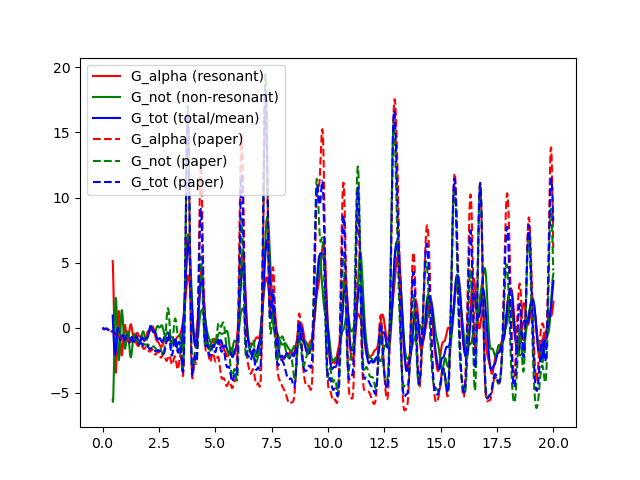

In [11]:
# v3 plotter
data = np.load("dpdf.npz")
dpdf_r_tot = data["r_tot"]
dpdf_G_a   = data["G_a"]
dpdf_G_na  = data["G_na"]
dpdf_G_tot = data["G_tot"]

r= np.arange(cfg.rmin, cfg.rmax + cfg.dr/2.0, cfg.dr)

r_cutoff = 45
plt.figure()
plt.plot(r[r_cutoff:], out['G_alpha'][r_cutoff:],'r', label="G_alpha (resonant)")
plt.plot(r[r_cutoff:], out['G_not'][r_cutoff:],'g', label="G_not (non-resonant)")
plt.plot(r[r_cutoff:], out['G_tot'][r_cutoff:],'b', label="G_tot (total/mean)")
plt.plot(dpdf_r_tot, dpdf_G_a,   'r--', label="G_alpha (paper)")
plt.plot(dpdf_r_tot, dpdf_G_na,  'g--', label="G_not (paper)")
plt.plot(dpdf_r_tot, dpdf_G_tot, 'b--', label="G_tot (paper)")


plt.legend()
plt.show()


## 1. Definitions

- Scattering factors for element i:

  ```math
  f_i(Q,E) = f_{0,i}(Q) + f'_i(E) + i\,f''_i(E)
  ```

* $f_0(Q)$ is the Thomson (real) form factor

* $f'$, $f''$ are the dispersive parts near an absorption edge

* Composition averages (Faber–Ziman):

  ```math
  \langle f \rangle(Q,E) = \sum_i c_i\,\Re f_i(Q,E)
  ```

  ```math
  \langle |f|^2 \rangle(Q,E) = \sum_i c_i\,|f_i(Q,E)|^2
  ```

* Corrections:

  ```math
  \alpha(E) = \alpha_C + \alpha_D\,f''(E)
  ```

  ```math
  \beta(E) = \beta_C + \beta_D\,f''(E)
  ```

* Background term $\beta_0(Q,E)$:

  * Even after normalization, small residuals cause $S \not\to 1$ at high $Q$.
  * Fit a polynomial in Q on a high-Q mask to drive $S \to 1$.

    Corrected intensity:

  ```math
  I_{\text{corr}}(Q,E) = \alpha(E)\,I_{\text{raw}}(Q,E) + \beta(E) + \beta_0(Q,E)
  ```

* Normalized structure function (target from the data):

  ```math
  S(Q,E) = \frac{I_{\text{corr}}(Q,E)-\langle |f|^2\rangle}{\langle f\rangle^2} + 1
  ```


* PDF:

  ```math
  G(r) = \frac{2}{\pi}\int_0^{Q_{\max}} Q \, [S(Q)-1] \, W(Q) \, \sin(Qr) \, dQ
  ```

  $W(Q)$ is a window function (e.g., Lorch/Kaiser) to suppress truncation ripples.

---

## 2. Edge Model (for $f'$ and $f''$)

* Near-edge $f''(E)$:
  Start from Chantler $f_2$ as baseline and refine:

  * global energy shift $dE$
  * scale on $f''$
  * offset and optional linear slope vs. E
  * optional Lorentzian white-line peaks $\sum_k L_k(E)$
  * Lorentzian broadening (convolution with FWHM parameter)

  Constraint: $f''(E) \geq 0$ (physical absorption).

* Computing $f'(E)$ via Kramers–Kronig:

  * Merge near-edge $f''$ with tabulated high/low-energy tails.

  * Compute $f_1(E)$, then:

    ```math
    f'(E) = f_1(E) - f_1(\infty)
    ```

  * Refine a small shift parameter `fp_offset` applied only to the weights $a$ and $b$.

* Form factor in weights:

  ```math
  \Re f_\alpha(Q,E) = f_0^\alpha(Q) + f'(E) + \text{fp\_offset}
  ```

  For non-resonant species, use $f_0(Q)$ only.

---

## 3. From Raw Intensity to $S(Q,E)$

* Energy contrast / two-channel model:

  * Choose a resonant species $\alpha$ (near an edge).

  * Decompose:

    ```math
    S(Q,E) = a(Q,E)\,S_\alpha(Q) + b(Q,E)\,S_{\lnot\alpha}(Q)
    ```

  * Mixing weights (composition + real parts):

    ```math
    a = \frac{c_\alpha\,\Re f_\alpha}{\langle f \rangle}, \quad
    b = \frac{\sum_{\beta \neq \alpha} c_\beta\,\Re f_\beta}{\langle f \rangle}
    ```

  * $S_\alpha$ and $S_{\lnot\alpha}$ are energy-independent unknown partial structure functions.

  * Optimization Problem:

	For each $Q_j$, solves regularized least-squares problem:

	```math
	\min_{x \in \mathbb{R}^2} \quad \|A_j x - y_j\|_2^2 \;+\; \lambda \|x\|_2^2 \;+\; \mu \|x - \mathbf{1}\|^2
	```

	```math
	\min_{S_\alpha, S_{\lnot\alpha}} 
	\sum_E \left[a_{Ej}S_\alpha + b_{Ej}S_{\lnot\alpha} - S_{Ej}\right]^2
	+ \lambda_{\text{ridge}}\|x\|^2
	+ \lambda_{\text{anchor}}(j)\|x-\mathbf{1}\|^2
	```

	Where:

	- $ A_j \in \mathbb{R}^{n_e \times 2} $ is the local design matrix, a/b channels.

	- $ y_j \in \mathbb{R}^{n_e \times 1} $ is the measurement $S$ vector for each Q.

	- $ x = \begin{bmatrix} s_\alpha \\ s_{\lnot\alpha} \end{bmatrix} $ are the two unknown coefficients to solve for in this column.

	- $\lambda = \texttt{ridge}$ is the ridge regularization strength, stabilize the solution.

	- $\mu = \texttt{anchor}$ is the anchor weight for high-Q tails (on high-Q mask, else 0).

---

## 4. Global refinement: parameters and constraints

* Global edge parameters:

  * $dE$ (eV), scale (>0), `fpp_offset`, `broaden_fwhm_eV`, `fp_offset`.

* Correction parameters:

  * $\alpha_C, \alpha_D, \beta_C, \beta_D$.

* Peaks:

  * center within measured energy span
  * FWHM $\in$ \[0.5, 30] eV
  * height $\geq$ 0, capped vs. baseline median, L1 penalty applied.

* Hard constraints:

  * $f''(E) \geq 0$
  * scale > 0
  * FWHM within limits
  * cap extreme $a, b$ weights to avoid blowups
  * anchoring for high-Q tails

---

## 6. Refinement Strategy

* Coordinate descent with adaptive steps:

  * Try $\pm\Delta$ per parameter; shrink $\Delta$ by $\times 0.7$ if rejected.

* Objective function:

  ```math
  J = \lambda_\text{tail}\sum_{j \in \text{hiQ}}\![(S_\alpha-1)^2 + (S_{\lnot\alpha}-1)^2]
  + \lambda_\text{smooth}\sum (\Delta^2 S_\alpha)^2 + (\Delta^2 S_{\lnot\alpha})^2
  + \lambda_{L1}\sum_k \text{height}_k
  ```

  Encourages:

  * Tails near 1
  * Smooth $Q$-dependence
  * Sparse peaks

* Peak birth/death:

  * Occasionally attempt to add peaks above edge.
  * Keep if J improves, remove if negligible.

